In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data = pd.read_csv('BodyFat.csv')
data.head()

,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,Y,M,23,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,Y,M,22,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,Y,M,22,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,Y,M,26,83.80,1.84,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,Y,M,24,83.58,1.81,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


## Data Cleaning 

Known Data Errors

The men's data (Johnson 1996) and women's data (Slack 1997) each have a couple of
recording errors documented in the original papers, and the dataset also contains one
physiologically impossible value `BodyFat == 0`.


In [46]:
# Rows flagged as (likely) recording errors by the source papers,
error_checks = {
    "BodyFat == 0": data[data['BodyFat'] == 0],
    "Age == 1 ": data[data['Age'] == 1],
    "Height < 1.0 m ": data[data['Height'] < 1.0],
    "Chest == 43.0 ": data[data['Chest'] == 43.0],
    "Chest == 49.5 ": data[data['Chest'] == 49.5],
    "Knee == 24.7 ": data[data['Knee'] == 24.7],
}

for label, rows in error_checks.items():
    print(label)
    display(rows)
    print()



BodyFat == 0


,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
181,0.0,Y,M,40,53.75,1.73,33.8,79.3,69.4,85.0,47.2,33.5,20.2,27.7,24.6,16.5



Age == 1 


,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
371,26.68,N,F,1,62.5968,1.64338,34.0,86.5,72.5,98.5,53.5,37.5,23.0,28.5,24.5,15.5



Height < 1.0 m 


...

,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
293,22.06,N,F,19,59.8752,1.66878,31.0,43.0,66.0,100.0,51.0,37.0,23.0,26.0,23.0,16.3



Chest == 49.5 


,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
386,21.44,N,F,23,52.164,1.651,29.5,49.5,61.0,93.5,48.5,35.0,21.5,26.5,22.7,16.0



Knee == 24.7 


,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
375,15.86,N,F,21,56.7,1.7145,30.5,85.5,71.0,93.0,49.0,24.7,21.5,25.0,22.5,15.0


In [7]:
# BodyFat == 0 corrupts the target itself, not a predictor — so it gets dropped
data = data.drop(data[data['BodyFat'] == 0].index)

# The remaining flagged cells are predictor errors we treat them as missing, then replace
# using the sex-specific median (so that a man's height typo isn't replaced using women's data)
data.loc[data['Age'] == 1, 'Age'] = np.nan
data.loc[data['Height'] < 1.0, 'Height'] = np.nan
data.loc[data['Chest'] == 43.0, 'Chest'] = np.nan
data.loc[data['Chest'] == 49.5, 'Chest'] = np.nan
data.loc[data['Knee'] == 24.7, 'Knee'] = np.nan

data[['Age', 'Height', 'Chest', 'Knee']] = (
    data.groupby('Sex')[['Age', 'Height', 'Chest', 'Knee']].transform(lambda col: col.fillna(col.median()))
)

data.isnull().sum()

BodyFat     0
Original    0
Sex         0
Age         0
Weight      0
Height      0
Neck        0
Chest       0
Abdomen     0
Hip         0
Thigh       0
Knee        0
Ankle       0
Biceps      0
Forearm     0
Wrist       0
dtype: int64

# Exploratory Data Analysis 

# Univariate Analysis


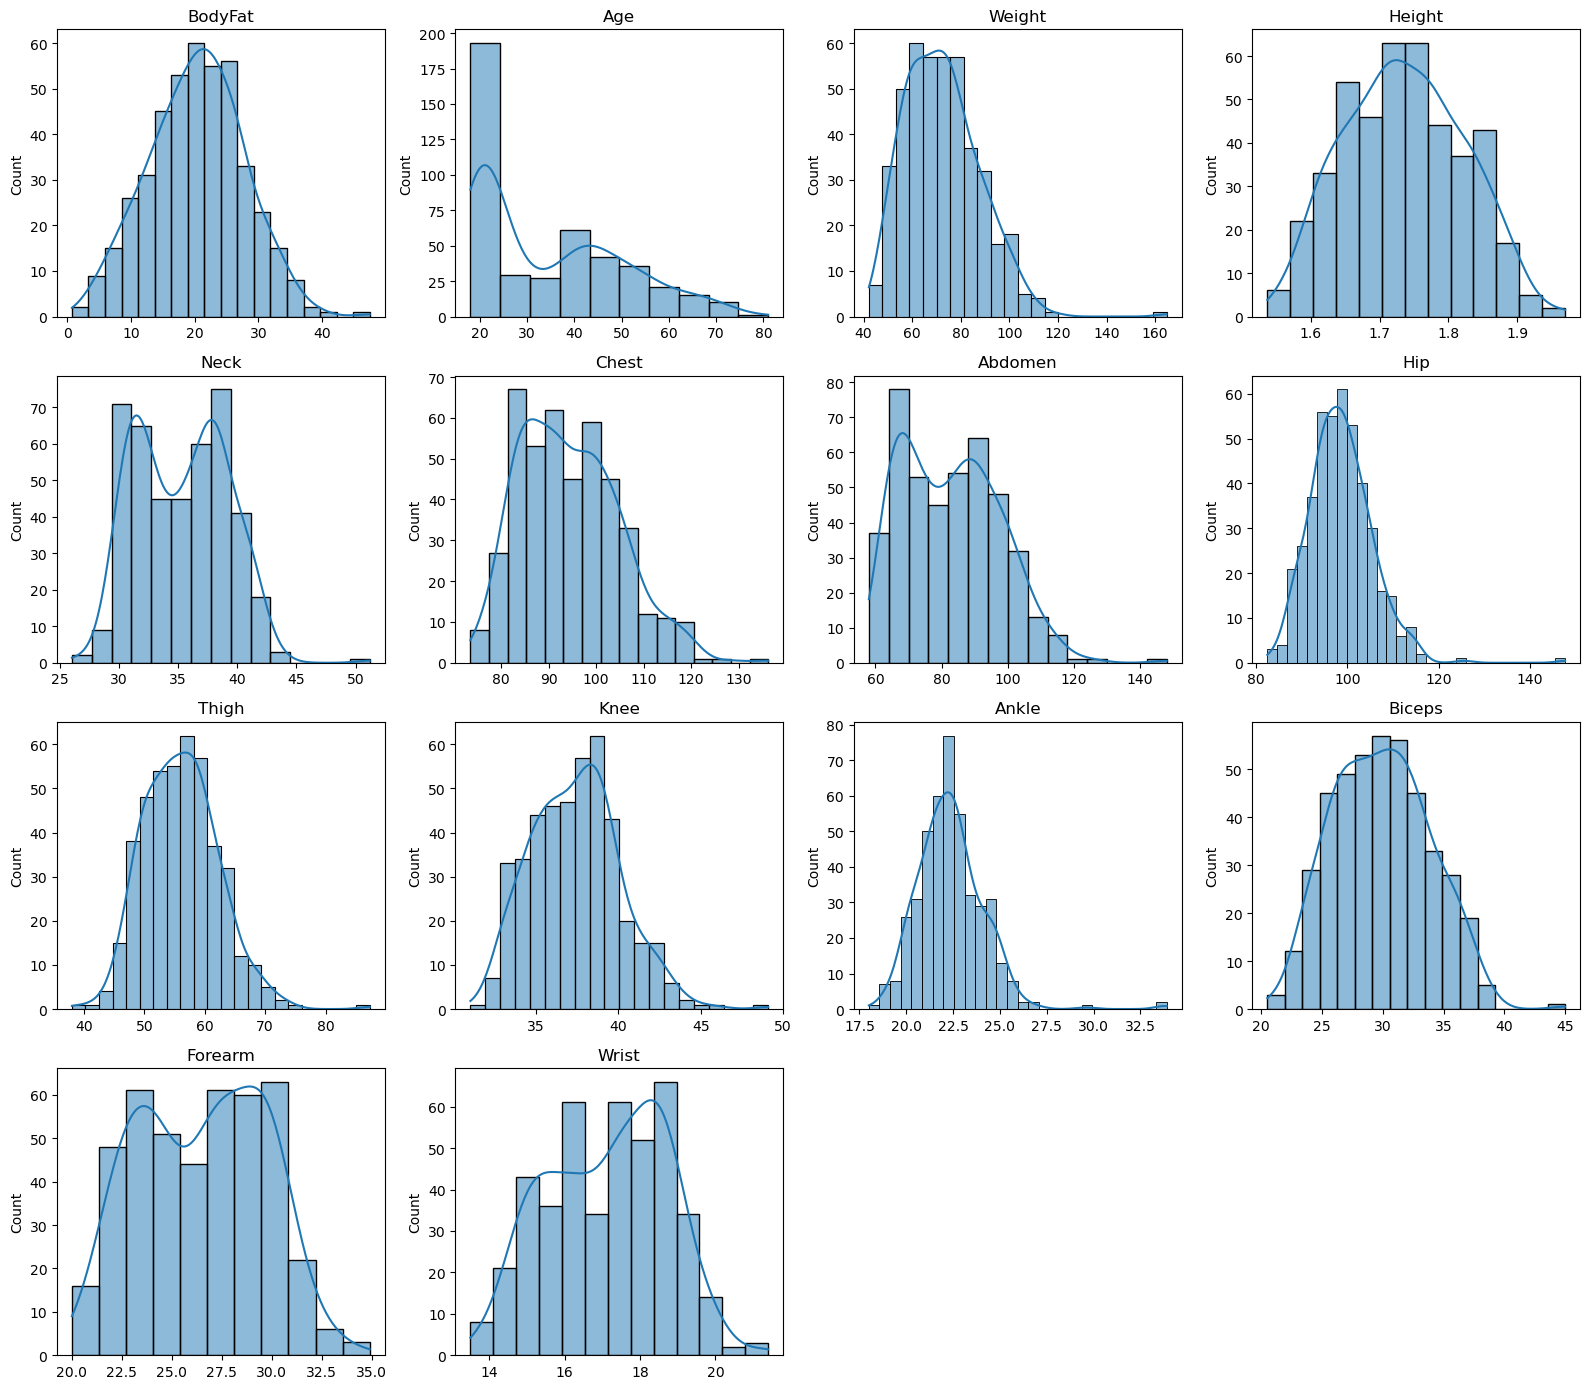

In [8]:
numerical_columns = data.select_dtypes(include=[np.number]).columns

n = len(numerical_columns)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):
    sns.histplot(data[column], kde=True, ax=ax)
    ax.set_title(column)
    ax.set_xlabel('')

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
print("Skewness (sorted):")
print(data[numerical_columns].skew().sort_values(ascending=False))

Skewness (sorted):
Ankle      1.438610
Hip        1.144792
Weight     0.829008
Age        0.701493
Chest      0.558984
Abdomen    0.487198
Thigh      0.484718
Knee       0.381722
Biceps     0.203735
Neck       0.188225
Height     0.088126
BodyFat    0.029233
Forearm    0.001469
Wrist     -0.099059
dtype: float64


**Insights:**
- `Ankle`, `Hip`, and `Weight` are the most right-skewed features among all features which is worth noting if we are dealing with outliers 
- `Age` still shows a long tail even after the fix because  this is real variation so it stays as-is.

## Bivariate Analysis (each feature vs. BodyFat)

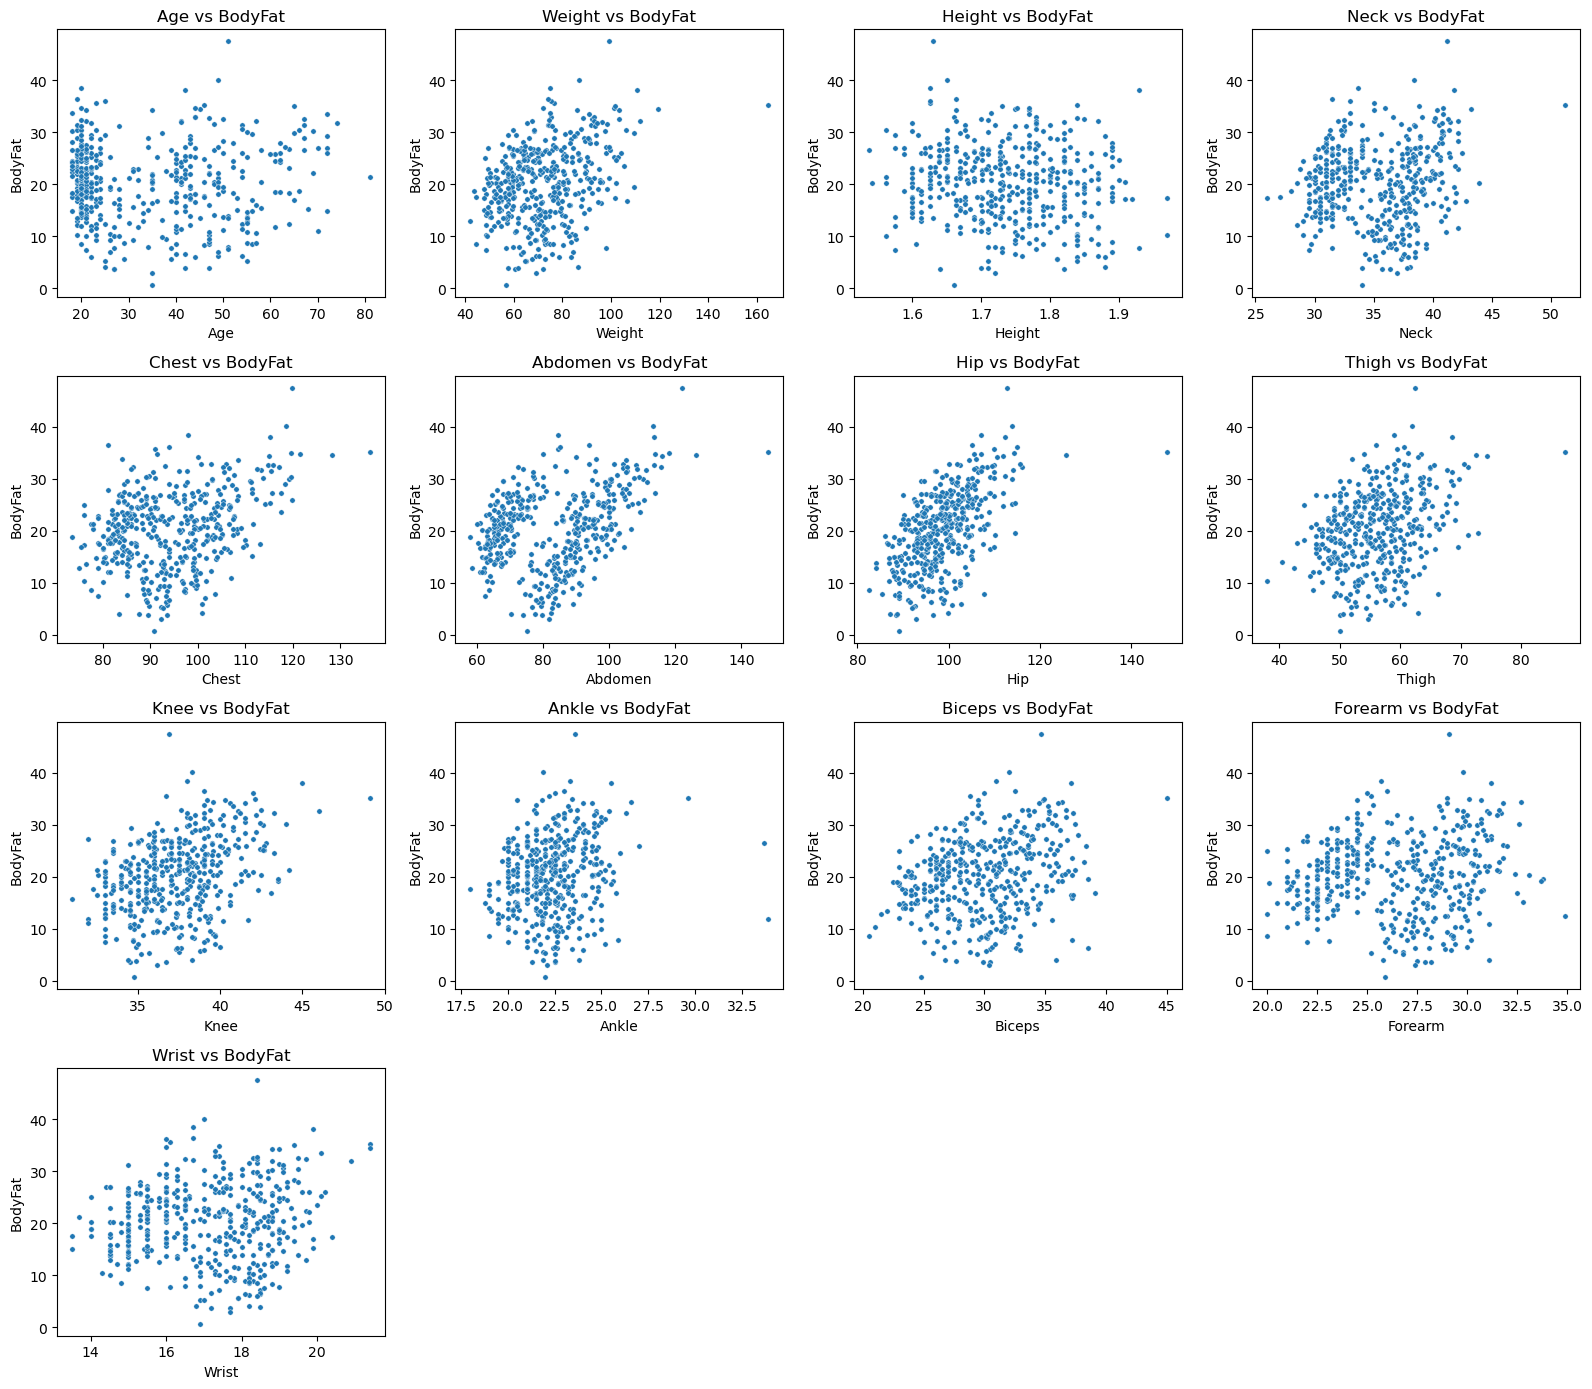

In [10]:
predictor_columns = [c for c in numerical_columns if c != 'BodyFat']

ncols = 4
nrows = int(np.ceil(len(predictor_columns) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax, column in zip(axes, predictor_columns):
    sns.scatterplot(data=data, x=column, y='BodyFat', ax=ax, s=15)
    ax.set_title(f'{column} vs BodyFat')

for ax in axes[len(predictor_columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Insight:**
- `Abdomen`, `Hip`, `Chest`, `Weight`, and `Thigh` show the clearest positive linear trend
  with `BodyFat` — these are the  strongest single predictors visually.
- `Age` and `Height` show almost no visible trend — flat and scattered  
- `Wrist` and `Ankle` show a weak trend with a lot of scatter 

## Multivariate Analysis

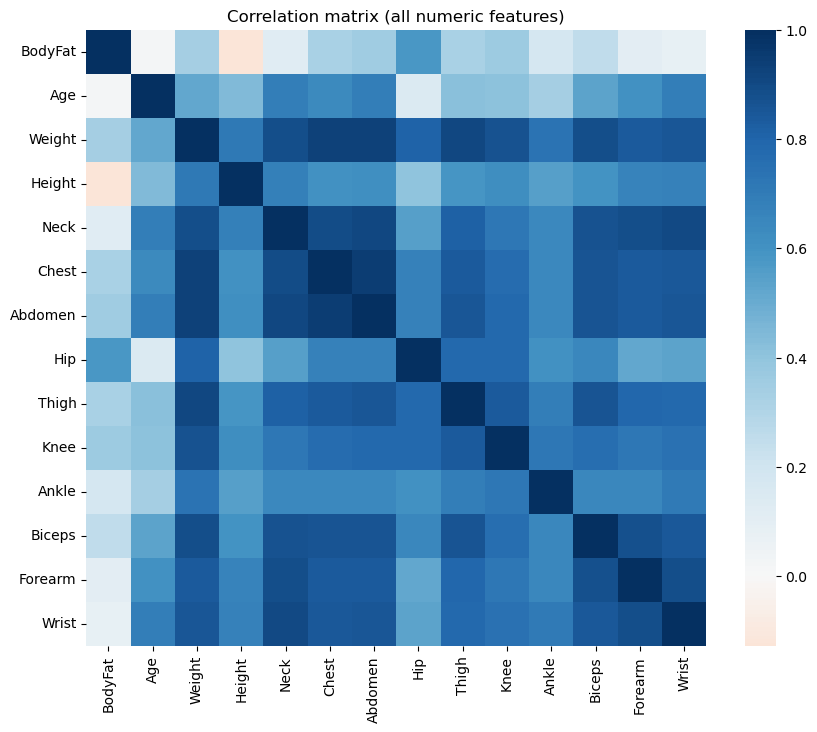

Correlation with BodyFat, sorted:
Hip        0.583707
Knee       0.365764
Abdomen    0.355104
Weight     0.341811
Thigh      0.325659
Chest      0.322645
Biceps     0.257015
Ankle      0.177016
Neck       0.120474
Forearm    0.103441
Wrist      0.087420
Age        0.020661
Height    -0.127019
Name: BodyFat, dtype: float64


In [11]:
#Correlation matrix
plt.figure(figsize=(10, 8))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap='RdBu', center=0, annot=False)
plt.title('Correlation matrix (all numeric features)')
plt.show()

print("Correlation with BodyFat, sorted:")
print(corr['BodyFat'].drop('BodyFat').sort_values(ascending=False))

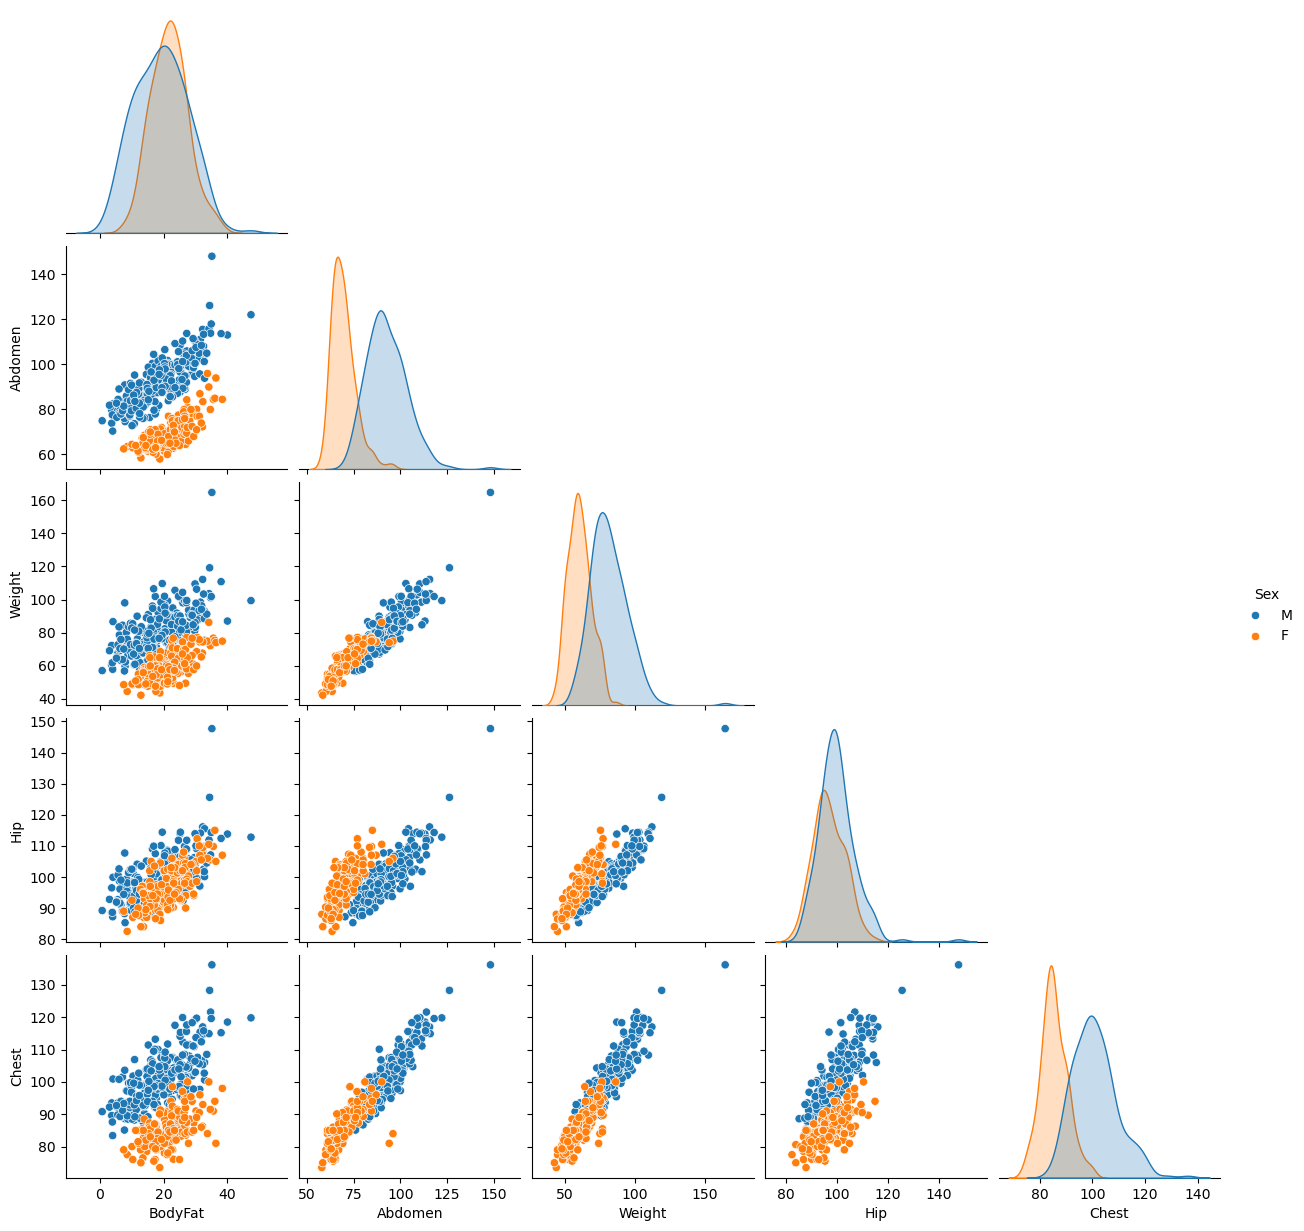

In [12]:
##  Pairplot 
key_features = ['BodyFat', 'Abdomen', 'Weight', 'Hip', 'Chest', 'Sex']
sns.pairplot(data[key_features], hue='Sex', corner=True)
plt.show()

## Outlier Analysis 

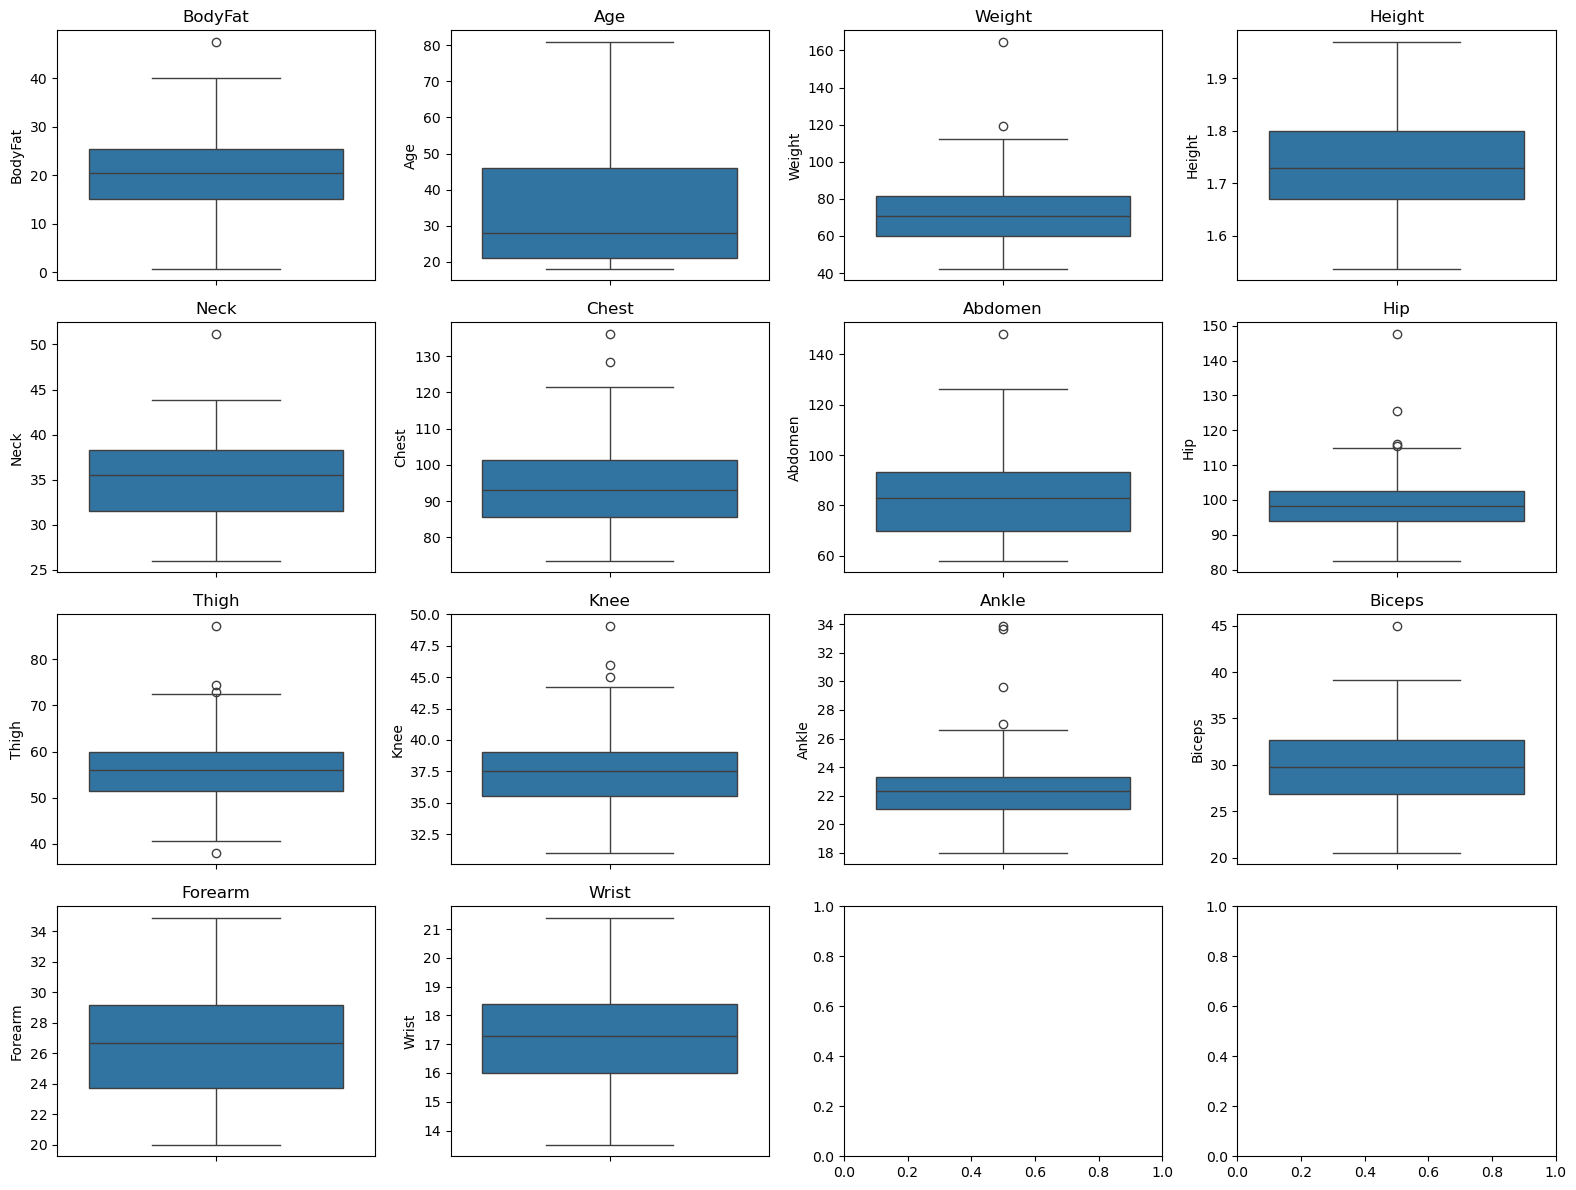

In [13]:
## --- Outlier detection (IQR method) ---
def iqr_outliers(col):
    Q1, Q3 = data[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return data[(data[col] < lower) | (data[col] > upper)]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns):
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [14]:
# Does mixing men and women together distort the correlations?
for sex_label, sex_name in [('M', 'Men'), ('F', 'Women')]:
    subset = data[data['Sex'] == sex_label]
    print(f"--- {sex_name} only (n={len(subset)}) ---")
    print(subset[['Abdomen', 'Hip', 'Weight']].corrwith(subset['BodyFat']).round(3))
    print()

--- Men only (n=251) ---
Abdomen    0.810
Hip        0.618
Weight     0.605
dtype: float64

--- Women only (n=184) ---
Abdomen    0.740
Hip        0.715
Weight     0.701
dtype: float64



**Insight (important):** `Abdomen`'s correlation with `BodyFat` is much stronger
*within* each sex (about 0.81 for men, 0.74 for women) than in the combined 436-row number
above (~0.36) which is clearly visible in the plot above where we can see two straight lines seperated by a distacne . Mixing both sexes together without accounting for `Sex` weakens down the signal . Also This is a strong argument for explicitly including `Sex` as a feature

In [15]:
data['Sex'] = data['Sex'].map({'M': 0, 'F': 1})
data.head()

,BodyFat,Original,Sex,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,Y,0,23.0,69.97,1.72,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,Y,0,22.0,78.59,1.84,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,Y,0,22.0,69.85,1.68,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,Y,0,26.0,83.80,1.84,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,Y,0,24.0,83.58,1.81,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


## Train / Test Split

Splitting before any outlier handling, scaling, or model fitting, so the test set stays
completely untouched until the very final evaluation. `Original` is dropped — it's
metadata about where the row came from, not a real predictor.

In [16]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['BodyFat', 'Original'])
y = data['BodyFat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(348, 14) (87, 14)


## Outlier Handling — Linear Pipeline Only, No Leakage

In [17]:
def get_iqr_bounds(df):
    bounds = {}
    for col in df.select_dtypes(include='number').columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds

def apply_clip(df, bounds):
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        df[col] = df[col].clip(lower, upper)
    return df

train_bounds = get_iqr_bounds(X_train)              
X_train_clipped = apply_clip(X_train, train_bounds)
X_test_clipped = apply_clip(X_test, train_bounds)   

## Feature Scaling

Only the linear models (Linear, Ridge, Lasso) need scaled input — tree-based models
(Decision Tree, Random Forest, XGBoost, LightGBM) split on thresholds and don't care about
feature scale. Fitting the scaler on the clipped training data only, then applying it to
the clipped test data.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_clipped), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_clipped), columns=X_test.columns, index=X_test.index)

## Models

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

def print_metrics(model, X_train_, y_train_, X_test_, y_test_, y_pred):
    mse = mean_squared_error(y_test_, y_pred)
    r2 = r2_score(y_test_, y_pred)
    print(f"Mean Squared Error: {mse:.3f}")
    print(f"R-squared: {r2:.3f}")
    print(f"Train set score: {model.score(X_train_, y_train_):.3f}")
    print(f"Test set score: {model.score(X_test_, y_test_):.3f}")

## Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred = lin_model.predict(X_test_scaled)
print_metrics(lin_model, X_train_scaled, y_train, X_test_scaled, y_test, y_pred)

Mean Squared Error: 13.183
R-squared: 0.660
Train set score: 0.723
Test set score: 0.660


## Ridge

In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]}

ridge_search = GridSearchCV(Ridge(), param_grid_ridge, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train)
print("Best alpha (Ridge): ", ridge_search.best_params_)
print("Best negative MSE (Ridge): ", ridge_search.best_score_)

ridge_model = ridge_search.best_estimator_
y_pred = ridge_model.predict(X_test_scaled)
print_metrics(ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, y_pred)

Best alpha (Ridge):  {'alpha': 1.0}
Best negative MSE (Ridge):  -18.133297918233666
Mean Squared Error: 13.007
R-squared: 0.665
Train set score: 0.722
Test set score: 0.665


## Lasso

In [49]:
from sklearn.linear_model import Lasso
param_grid_lasso = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}

lasso_search = GridSearchCV(Lasso(max_iter=10000), param_grid_lasso, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
lasso_search.fit(X_train_scaled, y_train)
print("Best alpha (Lasso): ", lasso_search.best_params_)
print("Best negative MSE (Lasso): ", lasso_search.best_score_)

lasso_model = lasso_search.best_estimator_
y_pred = lasso_model.predict(X_test_scaled)
print_metrics(lasso_model, X_train_scaled, y_train, X_test_scaled, y_test, y_pred)

Best alpha (Lasso):  {'alpha': 0.05}
Best negative MSE (Lasso):  -18.10630259005588
Mean Squared Error: 12.811
R-squared: 0.670
Train set score: 0.719
Test set score: 0.670


## Decision Tree

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
}

dt_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Best parameters found (Decision Tree): ", dt_search.best_params_)
print("Best negative mean squared error (Decision Tree): ", dt_search.best_score_)

dt_model = dt_search.best_estimator_
y_pred = dt_model.predict(X_test)
print_metrics(dt_model, X_train, y_train, X_test, y_test, y_pred)

Best parameters found (Decision Tree):  {'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best negative mean squared error (Decision Tree):  -29.632107153475538
Mean Squared Error: 26.649
R-squared: 0.313
Train set score: 0.780
Test set score: 0.313


Insight: Despite tuning via GridSearchCV, the single Decision Tree still shows a large train/test gap (0.78 vs 0.31) 
    this is a known property of single decision trees. one tree is high-variance by nature,
    since a handful of different splits near the top can send predictions in very different directions on unseen data.
    This is exactly the problem Random Forest and boosting were invented to fix by averaging many trees instead of trusting one.

## Random Forest

In [24]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best parameters found (Random Forest): ", rf_search.best_params_)
print("Best negative mean squared error (Random Forest): ", rf_search.best_score_)

rf_model = rf_search.best_estimator_
y_pred = rf_model.predict(X_test)
print_metrics(rf_model, X_train, y_train, X_test, y_test, y_pred)

Best parameters found (Random Forest):  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best negative mean squared error (Random Forest):  -22.013751108451626
Mean Squared Error: 15.224
R-squared: 0.608
Train set score: 0.920
Test set score: 0.608


## XGBoost

In [26]:
import xgboost as xgb

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

xgb_search = GridSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
                           param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best parameters found (XGBoost): ", xgb_search.best_params_)
print("Best negative mean squared error (XGBoost): ", xgb_search.best_score_)

xgb_model = xgb_search.best_estimator_
y_pred = xgb_model.predict(X_test)
print_metrics(xgb_model, X_train, y_train, X_test, y_test, y_pred)

Best parameters found (XGBoost):  {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best negative mean squared error (XGBoost):  -19.61772689475506
Mean Squared Error: 16.150
R-squared: 0.584
Train set score: 0.914
Test set score: 0.584


## LightGBM

In [27]:
from lightgbm import LGBMRegressor

param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, -1],
    'subsample': [0.7, 0.8, 0.9],
    'num_leaves': [15, 31, 63],
}

lgbm_search = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1),
                            param_grid_lgbm, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_search.fit(X_train, y_train)
print("Best parameters found (LightGBM): ", lgbm_search.best_params_)
print("Best negative mean squared error (LightGBM): ", lgbm_search.best_score_)

lgbm_model = lgbm_search.best_estimator_
y_pred = lgbm_model.predict(X_test)
print_metrics(lgbm_model, X_train, y_train, X_test, y_test, y_pred)

Best parameters found (LightGBM):  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.7}
Best negative mean squared error (LightGBM):  -20.28306154190439
Mean Squared Error: 14.136
R-squared: 0.636
Train set score: 0.853
Test set score: 0.636


## Comparing Different Models

In [50]:
model_scores = {
    "Linear Regression": lin_model.score(X_test_scaled, y_test),
    "Ridge": ridge_model.score(X_test_scaled, y_test),
    "Lasso": lasso_model.score(X_test_scaled, y_test),
    "Decision Tree": dt_model.score(X_test, y_test),
    "Random Forest": rf_model.score(X_test, y_test),
    "XGBoost": xgb_model.score(X_test, y_test),
    "LightGBM": lgbm_model.score(X_test, y_test),
}

for name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name} Test R-squared: {score:.4f}")

Lasso Test R-squared: 0.6697
Ridge Test R-squared: 0.6647
Linear Regression Test R-squared: 0.6601
LightGBM Test R-squared: 0.6356
Random Forest Test R-squared: 0.6075
XGBoost Test R-squared: 0.5836
Decision Tree Test R-squared: 0.3130


In [51]:
#As lasso ridge and linear are almost same and we had just trained them on only single train test split here we will check who dominates on 5 splits 
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("Linear Regression", LinearRegression()),
                     ("Ridge", Ridge(alpha=1.0)),
                     ("Lasso", Lasso(alpha=0.1))]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    print(f"{name}: mean R2 = {scores.mean():.4f}, std = {scores.std():.4f}, folds = {np.round(scores, 3)}")

Linear Regression: mean R2 = 0.6870, std = 0.0599, folds = [0.656 0.757 0.725 0.71  0.587]
Ridge: mean R2 = 0.6873, std = 0.0578, folds = [0.654 0.754 0.731 0.705 0.593]
Lasso: mean R2 = 0.6853, std = 0.0611, folds = [0.637 0.753 0.752 0.685 0.6  ]


## Final Model Selection & Test Set Evaluation

In [52]:
final_model = ridge_model
final_X_test = X_test_scaled

y_pred = final_model.predict(final_X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5

from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, y_pred)

print(f"Test R2:   {test_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}  (% body fat)")
print(f"Test MAE:  {test_mae:.3f}  (% body fat)")

Test R2:   0.665
Test RMSE: 3.607  (% body fat)
Test MAE:  2.934  (% body fat)


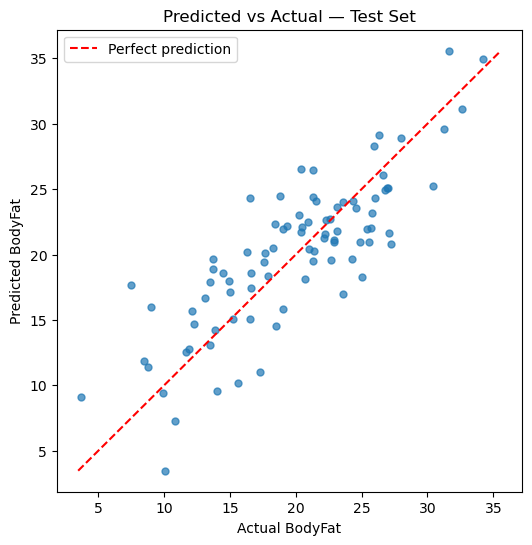

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=25, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual BodyFat')
plt.ylabel('Predicted BodyFat')
plt.title('Predicted vs Actual — Test Set')
plt.legend()
plt.show()

## Saving the Model for Deployment

Saving both the fitted model and the scaler — the deployed backend will need to apply the
exact same scaling (and clipping bounds, if the final model is from the linear pipeline) to
new user input before calling `.predict()`.

In [39]:
import joblib

joblib.dump(final_model, 'bodyfat_model.pkl')
joblib.dump(scaler, 'bodyfat_scaler.pkl')
joblib.dump(train_bounds, 'bodyfat_clip_bounds.pkl')  
print("Saved model, scaler, and clip bounds.")

Saved model, scaler, and clip bounds.
